In [1]:
import os
import rasterio as rio
import numpy as np
import pandas as pd


from spectral import envi
import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

from scipy.ndimage import binary_erosion
from pyproj import Transformer

import shapefile as shp
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='nl', target='en')

import Functions
import importlib

importlib.reload(Functions)

<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [2]:
print(translator.translate('hola'))

hola


In [3]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'

sentinel_path = Path('/media')/ 'frank' / 'USB' / 'SCUOLA' / 'App' / 'BACKSCATTER'

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [4]:
#img_dates = Functions.read_dates_from_stack(sentinel_path)

shapes = list(shape_path.glob('*.shp'))
hdrs = list(sentinel_path.glob('*.hdr'))
print(len(shapes))

27


Estraggo i poligoni dei campi

In [5]:
mypoly = {}

for file in shapes:
    file_stem = Path(file).stem
    
    # 1. Load and Transform in one go
    # This now returns a list of dicts: [{'objectid': 1, 'coords': [...]}, ...]
    poly_data_list = Functions.open_shp_with_geopandas(file)

    if poly_data_list is not None:

        for feature in poly_data_list:
            obj_id = feature['objectid']
            utm_coords = feature['coords']
            #tipo = feature['Type']                                
            
            # 3. Create Path objects for each part of the geometry
            # (Handling MultiPolygons by creating a list of Paths)
            paths = [mpth.Path(p) for p in utm_coords]
            
            mypoly[obj_id] = {
                'Name': file_stem,
                'id': obj_id,
                'coord': utm_coords,
                'path': paths
                #'Type': tipo
            }
            
            print(f"Successfully processed {file_stem} - {obj_id}.")
    else:
        print(f"Skipping file {file} because it is invalid or empty.")

print(f"Total files processed: {len(mypoly.keys())}")

Successfully processed DB_A_C - 1841224.
Successfully processed AKW_SB_C - 1936134.
An error occurred: Unable to open /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.shx or /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.
Skipping file /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.shp because it is invalid or empty.
Successfully processed KL_MA_1_C - 2088262.
Successfully processed HF3_WT_C - 1576641.
Successfully processed PE_A4_C - 1889482.
Successfully processed SB7_ER_C - 1697689.
Successfully processed KL_MA2-C - 1896343.
Succes

In [6]:
#print(translator.translate(mypoly[1767881]))

Reading SAR geographical coordinates

In [7]:
X_geo, Y_geo = Functions.axes_from_metadata(hdrs[0])

for key in mypoly:

    # 1. Find the total Bounding Box by merging all field parts
    # Stack all pieces to calculate global min/max
    all_coords = np.vstack(mypoly[key]['coord'])
    xmin, ymin = all_coords.min(axis=0)
    xmax, ymax = all_coords.max(axis=0)

    # 2. Find indices within the Sentinel image
    idx_x = np.where((X_geo >= xmin) & (X_geo <= xmax))[0]
    idx_y = np.where((Y_geo >= ymin) & (Y_geo <= ymax))[0]

    # 3. Create the point grid for cropping (Subset)
    r0, r1 = idx_y.min(), idx_y.max() + 1
    c0, c1 = idx_x.min(), idx_x.max() + 1

    X_sub = X_geo[c0:c1]
    Y_sub = Y_geo[r0:r1]
    
    # 4. Improved mask creation
    X_grid, Y_grid = np.meshgrid(X_sub, Y_sub)
    # Important: use stack to get clean (x, y) pairs
    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

    mymask_sub = np.zeros(X_grid.shape, dtype=bool)
    # Iterate over each Path object in the previously saved list
    for pth_obj in mypoly[key]['path']:
        # Create the mask for the single part and merge it using logical OR (|)
        # Use standard 'C' order and then .reshape()
        current_part_mask = pth_obj.contains_points(points).reshape(X_grid.shape)
        mymask_sub |= current_part_mask

    # Apply binary erosion to avoid edge effects
    mask_eroted = binary_erosion(mymask_sub, structure=np.ones((3,3))).astype(mymask_sub.dtype)
    mypoly[key]['mask_sub'] = mask_eroted # mymask_sub
    mypoly[key]['r_range'] = (r0, r1)
    mypoly[key]['c_range'] = (c0, c1)

# Final Debug
field = 1545384
print(f"Starting column index for {field}: {mypoly[field]['c_range'][0]}")
print(f"Eroded mask shape: {mypoly[field]['mask_sub'].shape}")

Starting column index for 1545384: 5374
Eroded mask shape: (24, 33)


In [8]:
print(mypoly[1545384])

{'Name': 'DB_SB2_C', 'id': 1545384, 'coord': [array([[ 687730.17665482, 5826640.96126354],
       [ 687779.84143728, 5826501.48980473],
       [ 687513.53043301, 5826404.84646717],
       [ 687500.67816902, 5826400.18911466],
       [ 687477.44027469, 5826467.32591813],
       [ 687451.14321192, 5826540.45437757],
       [ 687451.1512423 , 5826540.45739529],
       [ 687451.15399771, 5826540.44973148],
       [ 687453.53463716, 5826541.30832415],
       [ 687453.53228967, 5826541.31500081],
       [ 687730.17665482, 5826640.96126354]])], 'path': [Path(array([[ 687730.17665482, 5826640.96126354],
       [ 687779.84143728, 5826501.48980473],
       [ 687513.53043301, 5826404.84646717],
       [ 687500.67816902, 5826400.18911466],
       [ 687477.44027469, 5826467.32591813],
       [ 687451.14321192, 5826540.45437757],
       [ 687451.1512423 , 5826540.45739529],
       [ 687451.15399771, 5826540.44973148],
       [ 687453.53463716, 5826541.30832415],
       [ 687453.53228967, 5826541.315

ReadingSAR images and saving the average and the std in a dictionary:
poly_stats[name_polygon][data+VV/VH][avg/std]

In [9]:
poly_stats = {k: {} for k in mypoly}

for file in hdrs:

    file_path = Path(file)
    file_stem = file_path.stem
    date = file_stem[:8] # Assuming YYYYMMDD format
    
    # 1. Open the file (without loading it into RAM!)
    img_obj = Functions.read_img2(file, '')

    # Determine polarization from the filename
    pol = 'VH' if 'VH' in file_stem else 'VV'
    name = f'{date}_{pol}'

    print(f'Processing {pol} for date {date}...')

    for key in mypoly:
        r1, r2 = mypoly[key]['r_range']
        c1, c2 = mypoly[key]['c_range']
    
        # 2. READ ONLY THE SUBREGION FROM DISK
        # read_subregion( (r_start, r_end), (c_start, c_end) )
        radar_sub = img_obj.read_subregion((r1, r2), (c1, c2))
        
        # Squeeze dimensions (from (H, W, 1) to (H, W))
        radar_sub = np.squeeze(radar_sub)
    
        # 3. Apply the eroded mask
        pixel_campo = radar_sub[mypoly[key]['mask_sub']]

        if len(pixel_campo) > 0:
            if name not in poly_stats[key]:
                poly_stats[key][name] = {}
            
            # Linear scale calculation
            m_lin = np.mean(pixel_campo)
            s_lin = np.std(pixel_campo)
            
            # Saving results (you can also add dB conversion here)
            poly_stats[key][name]['mean'] = m_lin
            poly_stats[key][name]['std'] = s_lin

        else:
            print(f"Warning: no valid pixels for {key} in {file_stem}")

# Manual memory cleanup at the end of each file (optional)
del img_obj

Processing VH for date 20170104...
Processing VV for date 20170104...
Processing VH for date 20170110...
Processing VV for date 20170110...
Processing VH for date 20170116...
Processing VV for date 20170116...
Processing VH for date 20170122...
Processing VV for date 20170122...
Processing VH for date 20170128...
Processing VV for date 20170128...
Processing VH for date 20170203...
Processing VV for date 20170203...
Processing VH for date 20170209...
Processing VV for date 20170209...
Processing VH for date 20170215...
Processing VV for date 20170215...
Processing VH for date 20170221...
Processing VV for date 20170221...
Processing VH for date 20170227...
Processing VV for date 20170227...
Processing VH for date 20170305...
Processing VV for date 20170305...
Processing VH for date 20170311...
Processing VV for date 20170311...
Processing VH for date 20170317...
Processing VV for date 20170317...
Processing VH for date 20170323...
Processing VV for date 20170323...
Processing VH for da

In [10]:
print(poly_stats[1545384])

{'20170104_VH': {'mean': np.float32(-15.49018), 'std': np.float32(1.038437)}, '20170104_VV': {'mean': np.float32(-7.1632166), 'std': np.float32(1.0771589)}, '20170110_VH': {'mean': np.float32(-14.146261), 'std': np.float32(1.1360357)}, '20170110_VV': {'mean': np.float32(-5.746334), 'std': np.float32(1.0663439)}, '20170116_VH': {'mean': np.float32(-20.622658), 'std': np.float32(0.9228795)}, '20170116_VV': {'mean': np.float32(-11.156458), 'std': np.float32(0.84700435)}, '20170122_VH': {'mean': np.float32(-22.050701), 'std': np.float32(0.6946272)}, '20170122_VV': {'mean': np.float32(-10.921532), 'std': np.float32(0.9638198)}, '20170128_VH': {'mean': np.float32(-16.818918), 'std': np.float32(0.7312244)}, '20170128_VV': {'mean': np.float32(-7.0392795), 'std': np.float32(1.1325169)}, '20170203_VH': {'mean': np.float32(-16.139719), 'std': np.float32(1.0371394)}, '20170203_VV': {'mean': np.float32(-7.382657), 'std': np.float32(1.0008776)}, '20170209_VH': {'mean': np.float32(-21.579485), 'std':

Dataframe with statistics

In [11]:
Nme_types = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/areas_Flavoland.csv',header=0)
print(Nme_types)

         Name  Area_KM2     Code         Type   Unnamed: 4
0     PE_A1_C  0.068421  2294423          NaN          NaN
1     PE_A2_C  0.062289  1889479  Aardappelen   consumptie
2     PE_A3_C  0.050043  1697691  Aardappelen   consumptie
3     PE_A4_C  0.078363  1889482  Aardappelen   consumptie
4     PVD-M-C  0.090290  2278835         Maïs        snij-
5     RBW_A_C  0.078939  2081268  Aardappelen   consumptie
6      RBW_SB  0.079957  1601502       Bieten      suiker-
7     RBW_T_C  0.081114  2081267        Tarwe      winter-
8   SB10_MA_C  0.137161  2081887         Maïs        snij-
9    SB7_ER_C  0.090451  1697689     Grasland    tijdelijk
10   SB8_ER_C  0.078472  1697690     Grasland    tijdelijk
11    TK_MA_C  0.075782  1698168         Maïs        snij-
12    AKW_A_C  0.088083  1936133  Aardappelen   consumptie
13   AKW_G2_C  0.112435  1824038     Grasland    tijdelijk
14   AKW_SB_C  0.087198  1936134       Bieten      suiker-
15    AKW_T_C  0.113954  1936135        Tarwe      winte

In [12]:
Nme_types['Type'] = Nme_types['Type'].fillna('').astype(str)
Nme_types['Type']  = Nme_types['Type'].apply(lambda x: translator.translate(x))

In [13]:
print(Nme_types['Type'])

0              
1      Potatoes
2      Potatoes
3      Potatoes
4          Corn
5      Potatoes
6         Beets
7         Wheat
8          Corn
9     Grassland
10    Grassland
11         Corn
12     Potatoes
13    Grassland
14        Beets
15        Wheat
16    Grassland
17     Potatoes
18     Potatoes
19        Beets
20     Potatoes
21        Beets
22        Wheat
23     Potatoes
24        Wheat
25    Grassland
26         Corn
Name: Type, dtype: str


In [14]:
rows = []
for roi, dates_dict in poly_stats.items():
    for date_band, stats in dates_dict.items():
        row = {'Code': roi, 'Date_Band': date_band}
        row.update(stats) # Aggiunge 'mean', 'std', ecc. come colonne
        rows.append(row)

df_stats = pd.DataFrame(rows)

df_stats[['Date', 'Band']] = df_stats['Date_Band'].str.split('_', expand=True)
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
df_stats = df_stats.merge(Nme_types[['Code','Name', 'Type']], on='Code', how='left')

display(df_stats)


,Code,Date_Band,mean,std,Date,Band,Name,Type
0,1841224,20170104_VH,-14.988747,1.152336,2017-01-04,VH,DB_A_C,Potatoes
1,1841224,20170104_VV,-7.172247,1.059170,2017-01-04,VV,DB_A_C,Potatoes
2,1841224,20170110_VH,-13.919929,0.968011,2017-01-10,VH,DB_A_C,Potatoes
3,1841224,20170110_VV,-5.792219,0.991691,2017-01-10,VV,DB_A_C,Potatoes
4,1841224,20170116_VH,-20.690327,1.066293,2017-01-16,VH,DB_A_C,Potatoes
...,...,...,...,...,...,...,...,...
3181,1841225,20171218_VV,-5.278055,1.091359,2017-12-18,VV,DB_SB1_C,Beets
3182,1841225,20171224_VH,-13.429222,0.918860,2017-12-24,VH,DB_SB1_C,Beets
3183,1841225,20171224_VV,-5.429169,1.148561,2017-12-24,VV,DB_SB1_C,Beets
3184,1841225,20171230_VH,-12.458362,0.862726,2017-12-30,VH,DB_SB1_C,Beets


Visualizing the mask of a polygon and the mean value

-4.104316


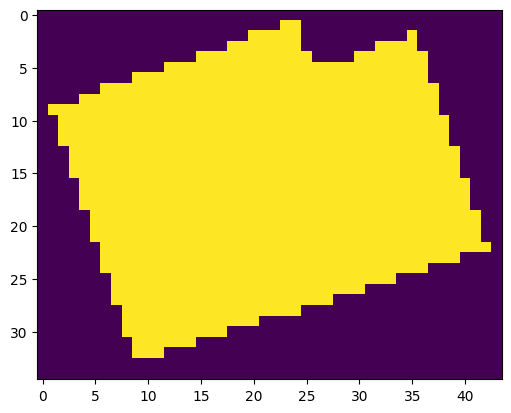

In [15]:
print(poly_stats[1841225]['20170305_VV']['mean'])
plt.imshow(mypoly[1841225]['mask_sub'])

(6346, 7025)



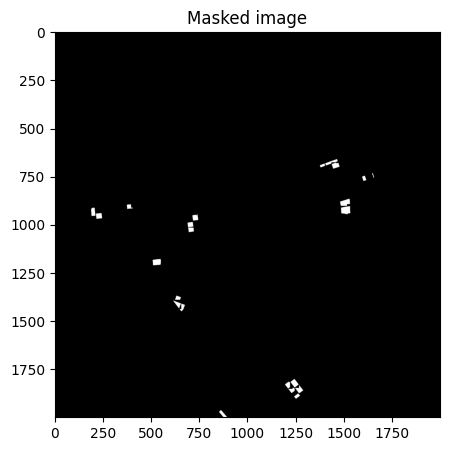

In [16]:
full_mask = np.zeros((len(Y_geo), len(X_geo)), dtype=bool)
print(full_mask.shape)

_ , IMG = Functions.read_img(hdrs[0],'')

# 2. Inserisci la maschera piccola nella posizione corretta usando gli indici
# idx_y e idx_x definiscono le "coordinate matriciali" in cui incollare il pezzo
print()
for i in mypoly:

    full_mask[mypoly[i]['r_range'][0]:mypoly[i]['r_range'][1], 
              mypoly[i]['c_range'][0]:mypoly[i]['c_range'][1]] = mypoly[i]['mask_sub']

plt.figure(figsize=(5,5))
plt.imshow(full_mask[1000:3000,4000:6000], cmap='gray')
plt.title("Masked image")
plt.show()

In [17]:
df_stats.to_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/TimeSeries_sigma.csv', index=False)

In [18]:
display(df_stats)

,Code,Date_Band,mean,std,Date,Band,Name,Type
0,1841224,20170104_VH,-14.988747,1.152336,2017-01-04,VH,DB_A_C,Potatoes
1,1841224,20170104_VV,-7.172247,1.059170,2017-01-04,VV,DB_A_C,Potatoes
2,1841224,20170110_VH,-13.919929,0.968011,2017-01-10,VH,DB_A_C,Potatoes
3,1841224,20170110_VV,-5.792219,0.991691,2017-01-10,VV,DB_A_C,Potatoes
4,1841224,20170116_VH,-20.690327,1.066293,2017-01-16,VH,DB_A_C,Potatoes
...,...,...,...,...,...,...,...,...
3181,1841225,20171218_VV,-5.278055,1.091359,2017-12-18,VV,DB_SB1_C,Beets
3182,1841225,20171224_VH,-13.429222,0.918860,2017-12-24,VH,DB_SB1_C,Beets
3183,1841225,20171224_VV,-5.429169,1.148561,2017-12-24,VV,DB_SB1_C,Beets
3184,1841225,20171230_VH,-12.458362,0.862726,2017-12-30,VH,DB_SB1_C,Beets


GRAFICI DELLE STATISTICHE

In [19]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = app_path / 'Documents'
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Time_Series_ROI_BACKSCATTER.pdf'

with PdfPages(pdf_filename) as pdf:
    unique_rois = df_stats['Code'].unique()

    for (roi, roi_type, crop), group in df_stats.groupby(['Code', 'Name', 'Type']):
        # Crea la figura
        plt.figure(figsize=(12, 6))
        roi_data = df_stats[df_stats['Code'] == roi]
        
        for band in roi_data['Band'].unique():
            band_data = roi_data[roi_data['Band'] == band]
            
            # Plot della linea media
            line, = plt.plot(band_data['Date'], band_data['mean'], 
                             marker='o', linestyle='-', linewidth=2, label=f'Mean {band}')
            
            # Area della deviazione standard (Mean ± Std) con rf'' per LaTeX
            plt.fill_between(
                band_data['Date'], 
                band_data['mean'] - band_data['std'], 
                band_data['mean'] + band_data['std'], 
                color=line.get_color(), 
                alpha=0.15, 
                label=rf'Dispersion $\pm 1\sigma$ ({band})'
            )

        # Formattazione estetica
        plt.title(f"ROI: {roi} ({roi_type} - {crop})", fontsize=14, fontweight='bold')
        plt.xlabel("Data", fontsize=12)
        plt.ylabel("Value (Reflectance / Backscatter)", fontsize=12)
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Legenda fuori dal grafico
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        pdf.savefig()
        
        plt.close()

print(f"Done! All graphs had been saved in : {pdf_filename}")


Done! All graphs had been saved in : /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/Time_Series_ROI_BACKSCATTER.pdf
